<a href="https://colab.research.google.com/github/duddet01/Biological_modeling/blob/main/Scaling_relation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

try:
  file_path = "https://docs.google.com/spreadsheets/d/1yLXpqa1l7GHjoj8I3Cg-pkUnryxjxViK/export?format=xlsx"
  df = pd.read_excel(file_path, sheet_name="Master_Cell_Data")


except IOError:
  print ("File not found!!!")




In [ ]:
#Loading in the data and filtering: (Male)

df = df.dropna(subset=["Male_cell_mass_g", "Male_cell_count"])
df = df[(df["Male_cell_mass_g"] > 0) & (df["Male_cell_count"] > 0)]

cell_mass = df["Male_cell_mass_g"].values
cell_count = df["Male_cell_count"].values

print(f"Size of dataset: {len(cell_mass)}")

Size of dataset: 1108


In [ ]:
#Loading in the data and filtering: (Female)

# df = df.dropna(subset=["Female_cell_mass_g", "Female_cell_count"])
# df = df[(df["Female_cell_mass_g"] > 0) & (df["Female_cell_count"] > 0)]

# cell_mass = df["Female_cell_mass_g"].values
# cell_count = df["Female_cell_count"].values

# print(f"Size of dataset: {len(cell_mass)}")

Size of dataset: 1052


Fitted power law: Cell Count ∝ 6.166e+01 * (Cell Mass)^-0.734
Slope (b): -0.734


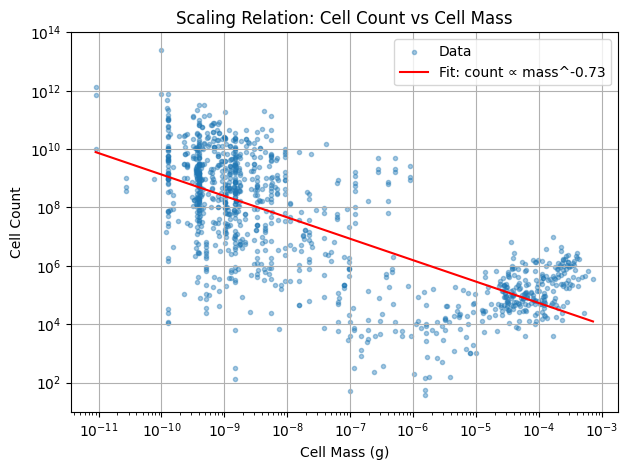

In [ ]:

# Graph w/o binning :


def power_law(x, A, b):
    return A * x**b


def linear_func(logx,logA,b):
  return logA+b*logx

# Fitting the log data linearly:

popt, pcov = curve_fit(linear_func, np.log10(cell_mass),np.log10(cell_count))

logA, b = popt
A = 10**logA

print(f"Fitted power law: Cell Count ∝ {A:.3e} * (Cell Mass)^{b:.3f}")
print(f"Slope (b): {b:.3f}")

# Plot:

plt.scatter((cell_mass),(cell_count), alpha=0.4, s= 9 , label="Data")

# Fitted curve:

x_fit = np.logspace(np.log10(cell_mass.min()), np.log10(cell_mass.max()), 200)
y_fit = power_law(x_fit, A, b)
plt.plot(x_fit, y_fit, 'r-', label=f"Fit: count ∝ mass^{b:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cell Mass (g)")
plt.ylabel("Cell Count")
plt.title("Scaling Relation: Cell Count vs Cell Mass")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


Fitted power law: Cell Count ∝ 4.104e+03 * (Cell Mass)^-0.808
Slope (b): -0.808


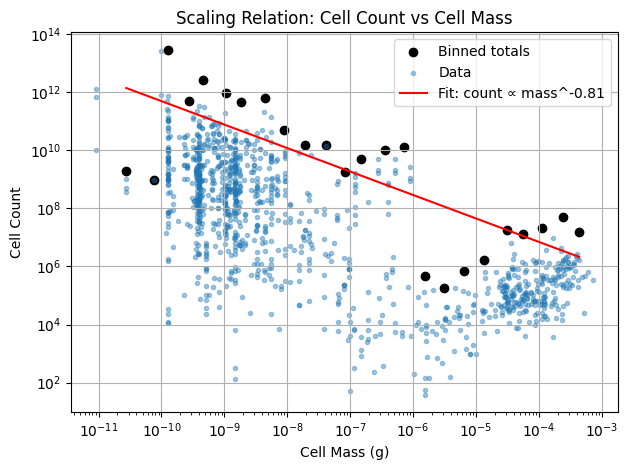

In [ ]:


# Graph with binning:

# Define log-spaced bins for cell mass:
n_bins = 26
bins = np.logspace(np.log10(cell_mass.min()), np.log10(cell_mass.max()), n_bins)
bin_indices = np.digitize(cell_mass, bins)

# Aggregate total cell counts per bin:
bin_centers, total_counts = [], []
for i in range(1, len(bins)):
    mask = bin_indices == i
    if mask.sum() > 0:
        bin_centers.append(np.mean(cell_mass[mask]))
        total_counts.append(np.sum(cell_count[mask]))

bin_centers = np.array(bin_centers)
total_counts = np.array(total_counts)

# Define explicit power-law function:

def power_law(x, A, b):
    return A * x**b

# What logY is equal to :

def linear_func(logx,logA,b):
  return logA+b*logx

# Fit in log–log space:
popt, pcov = curve_fit(linear_func, np.log10(bin_centers),np.log10(total_counts))

logA, b = popt
A = 10**logA

print(f"Fitted power law: Cell Count ∝ {A:.3e} * (Cell Mass)^{b:.3f}")
print(f"Slope (b): {b:.3f}")

# Plot:

plt.scatter(bin_centers, total_counts, color="black", label="Binned totals")
plt.scatter( cell_mass,cell_count, alpha=0.4, s= 9 , label="Data")

# Fitted curve:

x_fit = np.logspace(np.log10(bin_centers.min()), np.log10(bin_centers.max()), 200)
y_fit = power_law(x_fit, A, b)
plt.plot(x_fit, y_fit, 'r-', label=f"Fit: count ∝ mass^{b:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cell Mass (g)")
plt.ylabel("Cell Count")
plt.title("Scaling Relation: Cell Count vs Cell Mass")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-361261761.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear_func, np.log10(bin_centers),np.log10(total_counts))


Mean fitting parameter : -0.866 


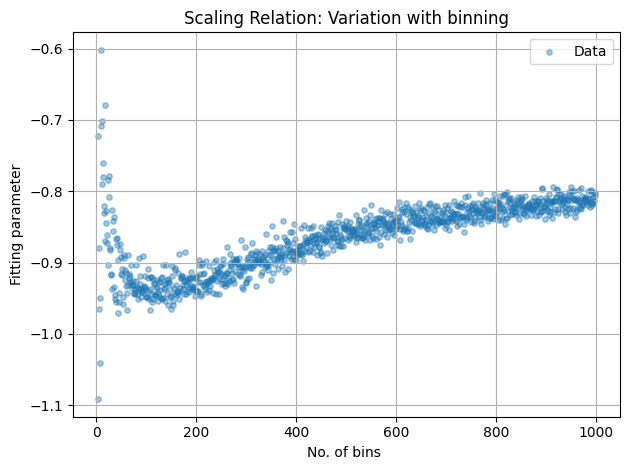

In [ ]:
#Perform operations ------

def power_law(x, A, b):
    return A * x**b


def linear_func(logx,logA,b):
  return logA+b*logx

# df = df.dropna(subset=["Male_cell_mass_g", "Male_cell_count"])
# df = df[(df["Male_cell_mass_g"] > 0) & (df["Male_cell_count"] > 0)]

# cell_mass = df["Male_cell_mass_g"].values
# cell_count = df["Male_cell_count"].values

fit_value=[]
n_bin=[]

for i in range(3,1000):
    n_bins = i
    n_bin.append(i)
    bins = np.logspace(np.log10(cell_mass.min()), np.log10(cell_mass.max()), n_bins)
    bin_indices = np.digitize(cell_mass, bins)


    bin_centers, total_counts = [], []
    for i in range(1, len(bins)):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_centers.append(np.mean(cell_mass[mask]))
            total_counts.append(np.sum(cell_count[mask]))

    bin_centers = np.array(bin_centers)
    total_counts = np.array(total_counts)

    popt, pcov = curve_fit(linear_func, np.log10(bin_centers),np.log10(total_counts))

    logA, b = popt

    fit_value.append(b)




print(f"Mean fitting parameter : {np.mean(fit_value):.3f} ")




plt.scatter( n_bin, fit_value , alpha=0.4, s= 15 , label="Data")

plt.xlabel("No. of bins ")
plt.ylabel("Fitting parameter")
plt.title("Scaling Relation: Variation with binning")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
target=-1.0
idx = (np.abs(np.array(fit_value) - target)).argmin()
val = fit_value[idx]
bins=np.array(n_bin)[idx]

print(f"Closest value: {val}, No of bins: {bins}")

Closest value: -0.9711079203321683, No of bins: 44


This is the cell type dataset obained by taking average of each cell type data and dropping entries without values(Nan)

In [ ]:
df_male = df[["Cell_type", "Male_cell_mass_g", "Male_cell_count"]].dropna()

# --- Group by Cell Type (take mean for each) ---
grouped = df_male.groupby("Cell_type").mean().reset_index()

# --- Data for fitting ---
x = grouped["Male_cell_mass_g"].values
y = grouped["Male_cell_count"].values



Fitted power law: Cell Count ∝ 1.250e-01 * (Cell Mass)^-1.064
Slope (b): -1.064


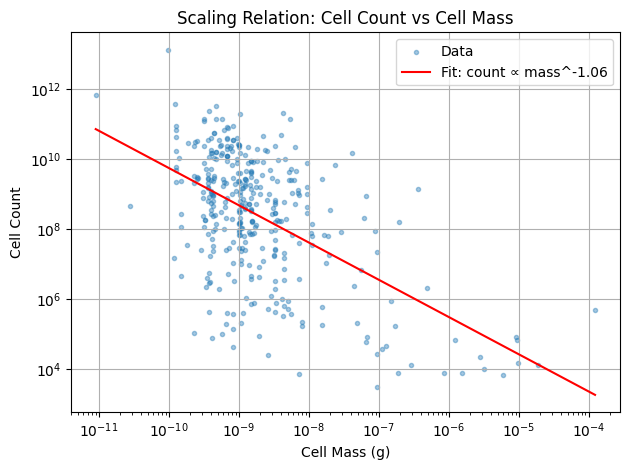

In [ ]:

# Graph w/o binning with cell type dataset:


def power_law(x, A, b):
    return A * x**b


def linear_func(logx,logA,b):
  return logA+b*logx

# Fitting the log data linearly:

popt, pcov = curve_fit(linear_func, np.log10(x),np.log10(y))

logA, b = popt
A = 10**logA

print(f"Fitted power law: Cell Count ∝ {A:.3e} * (Cell Mass)^{b:.3f}")
print(f"Slope (b): {b:.3f}")

# Plot:

plt.scatter((x),(y), alpha=0.4, s= 9 , label="Data")

# Fitted curve:

x_fit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_fit = power_law(x_fit, A, b)
plt.plot(x_fit, y_fit, 'r-', label=f"Fit: count ∝ mass^{b:.2f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Cell Mass (g)")
plt.ylabel("Cell Count")
plt.title("Scaling Relation: Cell Count vs Cell Mass")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
